In [24]:
%load_ext autoreload
%autoreload 2

In [25]:
import contextlib
import copy
import io
import os
import queue
import threading
from datetime import date
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import nse, kge, mkge, kge_r, kge_beta, kge_alpha, mkge_alpha
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameters_running_jablje import (
    jablje_soil_layers,
    jablje_curve_number,
    jablje_readily_evaporable_water,
    jablje_maize_params,
    jablje_management,
    jablje_initial_cond,
    jablje_groundwater,
)

In [26]:
LOCATION = "jablje"
MAX_WORKERS = os.cpu_count()

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024)
    if year not in [2017]
]

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_biomass = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")
observed_grain   = get_yield_for_comparison(LOCATION, "grain",   "A", "N3")

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}

In [27]:
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.MODEL_RUNNING_DIR / f"de_jablje_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories ready: {MAX_WORKERS}")

In [28]:
param_names = [
    "harvest_index",
    "gdd_emergence",
    "gdd_max_rooting",
    "gdd_senescence",
    "gdd_maturity",
    "gdd_flowering",
    "gdd_flowering_length",
    "gdd_hi_start",
    "max_canopy_cover",
    #"cgc_gdd",
    #"cdc_gdd",
    #"ksat",
    "min_rooting_depth",
    "max_rooting_depth",
    "p_upper_senescence",
    "p_upper_stomata"
]

bounds = [
    (0.46, 0.6),    # harvest_index
    (5, 60),        # gdd_emergence
    (700, 1000),    # gdd_max_rooting
    (700, 1000),    # gdd_senescence
    (900, 1200),    # gdd_maturity
    (400,  530),    # gdd_flowering
    (90,  170),    # gdd_flowering_length
    (300, 500),     # gdd_hi_start
    (0.85, 0.97),   # max_canopy_cover
    #(0.005, 0.03),  # cgc_gdd
    #(0.005, 0.02),  # cdc_gdd
    #(5, 1000),      # ksat
    (0.05, 0.4),    # min_rooting_depth
    (0.5, 2.5),     # max_rooting_depth
    #(0.4, 0.8),     # p_upper_senescence
    #(0.4, 0.8),     # p_upper_stomata
]

print(f"Parameters: {param_names}")
print(f"Bounds:     {bounds}")

In [29]:
def evaluate_params(param_values):
    """Run one candidate and return all metrics for both grain and biomass."""
    working_dir = dir_queue.get()
    try:
        params = copy.deepcopy(jablje_maize_params)
        for name, val in zip(param_names, param_values):
            params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        crop = Crop(
            name=f"{LOCATION} maize",
            description="differential evolution",
            params=params,
        )

        simulation = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=soil,
            management=jablje_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            ground_water=jablje_groundwater,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_metrics = {
            f"{prefix}_{s}": np.nan
            for prefix in ("biomass", "grain")
            for s in ["rmse", "r2", "nse", "kge", "mkge", "kge_r", "kge_beta", "kge_alpha", "mkge_alpha"]
        }

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return nan_metrics

        seasonal = results["season"][["Year1", "BioMass", "Y(dry)"]].rename(
            columns={"Year1": "year", "BioMass": "biomass_modeled", "Y(dry)": "grain_modeled"}
        )

        def compute_metrics(observed_df, modeled_col, prefix):
            merged = observed_df.merge(seasonal[["year", modeled_col]], on="year")
            y_obs = merged["yield"].values
            y_mod = merged[modeled_col].values
            return {
                f"{prefix}_rmse":       root_mean_squared_error(y_obs, y_mod),
                f"{prefix}_r2":         r2_score(y_obs, y_mod),
                f"{prefix}_nse":        nse(y_mod, y_obs),
                f"{prefix}_kge":        kge(y_mod, y_obs),
                f"{prefix}_mkge":       mkge(y_mod, y_obs),
                f"{prefix}_kge_r":      kge_r(y_mod, y_obs),
                f"{prefix}_kge_beta":   kge_beta(y_mod, y_obs),
                f"{prefix}_kge_alpha":  kge_alpha(y_mod, y_obs),
                f"{prefix}_mkge_alpha": mkge_alpha(y_mod, y_obs),
            }

        return {
            **compute_metrics(observed_biomass, "biomass_modeled", "biomass"),
            **compute_metrics(observed_grain,   "grain_modeled",   "grain"),
        }
    finally:
        dir_queue.put(working_dir)

In [32]:
eval_log = []          # collects every evaluated candidate for post-analysis
eval_log_lock = threading.Lock()

def make_scalar_objective(objective_fn):
    """Scalar objective for one candidate (used by thread_map workers)."""
    def scalar(param_values):
        r = evaluate_params(param_values)
        with eval_log_lock:
            eval_log.append({**dict(zip(param_names, param_values)), **r})
        return objective_fn(r)
    return scalar

def thread_map(func, iterable):
    """Drop-in map replacement for scipy workers= that uses ThreadPoolExecutor."""
    items = list(iterable)
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        return list(executor.map(func, items))


mean_biomass = observed_biomass["yield"].mean()
mean_grain   = observed_grain["yield"].mean()
print(f"Mean observed biomass: {mean_biomass:.1f}  |  mean observed grain: {mean_grain:.1f}")

objectives = {
    "biomass_rmse":   make_scalar_objective(lambda r: r["biomass_rmse"]),
    "grain_rmse":     make_scalar_objective(lambda r: r["grain_rmse"]),
    "combined_nrmse": make_scalar_objective(
        lambda r: r["biomass_rmse"] / mean_biomass + r["grain_rmse"] / mean_grain
    ),
}

In [33]:
DE_SETTINGS = dict(
    bounds=bounds,
    strategy="best1bin",
    maxiter=10,
    popsize=5,
    tol=1e-4,
    mutation=(0.5, 1.0),
    recombination=0.7,
    seed=42,
    workers=thread_map,
    updating="deferred",
    disp=True,
)

n_pop = DE_SETTINGS["popsize"] * len(bounds)
print(f"Population size: {n_pop}  |  max evaluations: {n_pop * DE_SETTINGS['maxiter']:,}")

In [35]:
convergence_log = {}

def make_convergence_callback(label):
    """Build a `differential_evolution` callback that records the best-so-far
    objective value after each generation into `convergence_log[label]`.

    Uses the new-style scipy callback signature (a single `intermediate_result`
    argument carrying an `OptimizeResult`-like object with `.fun`/`.x`).
    """
    history = []
    convergence_log[label] = history

    def callback(intermediate_result):
        history.append(intermediate_result.fun)

    return callback

In [36]:
eval_log.clear()
print("=== Optimising for BIOMASS RMSE ===")
result_biomass = differential_evolution(objectives["biomass_rmse"], **DE_SETTINGS, callback=make_convergence_callback("biomass_rmse"))
print(f"\nSuccess: {result_biomass.success}  |  message: {result_biomass.message}")
print(f"Function evaluations: {result_biomass.nfev}")
print(f"Best biomass RMSE: {result_biomass.fun:.4f}")
print("Best parameters:")
for name, val in zip(param_names, result_biomass.x):
    print(f"  {name}: {val:.4f}")

In [12]:
eval_log.clear()
print("=== Optimising for GRAIN RMSE ===")
result_grain = differential_evolution(objectives["grain_rmse"], **DE_SETTINGS, callback=make_convergence_callback("grain_rmse"))
print(f"\nSuccess: {result_grain.success}  |  message: {result_grain.message}")
print(f"Function evaluations: {result_grain.nfev}")
print(f"Best grain RMSE: {result_grain.fun:.4f}")
print("Best parameters:")
for name, val in zip(param_names, result_grain.x):
    print(f"  {name}: {val:.4f}")

In [13]:
eval_log.clear()
print("=== Optimising for COMBINED normalised RMSE (biomass + grain) ===")
result_combined = differential_evolution(objectives["combined_nrmse"], **DE_SETTINGS, callback=make_convergence_callback("combined_nrmse"))
print(f"\nSuccess: {result_combined.success}  |  message: {result_combined.message}")
print(f"Function evaluations: {result_combined.nfev}")
print(f"Best combined nRMSE: {result_combined.fun:.6f}")
print("Best parameters:")
for name, val in zip(param_names, result_combined.x):
    print(f"  {name}: {val:.4f}")

In [14]:
# Re-evaluate each best solution to get the full metric set
de_runs = {
    "biomass_rmse":   result_biomass.x,
    "grain_rmse":     result_grain.x,
    "combined_nrmse": result_combined.x,
}

summary_rows = []
for run_name, x in de_runs.items():
    metrics = evaluate_params(x)
    row = {"optimised_for": run_name, **dict(zip(param_names, x)), **metrics}
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("optimised_for")
summary_df

,gdd_emergence,gdd_max_rooting,gdd_senescence,gdd_maturity,max_canopy_cover,min_rooting_depth,max_rooting_depth,p_upper_senescence,p_upper_stomata,biomass_rmse,...,biomass_mkge_alpha,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
optimised_for,,,,,,,,,,,,,,,,,,,,,
biomass_rmse,9.185835,836.869406,972.962181,1186.401408,0.968649,0.312159,0.642812,0.666731,0.460049,4.641614,...,0.660261,2.956022,-1.075268,-1.075268,0.264560,0.348280,0.431170,0.758076,0.601531,0.793497
grain_rmse,5.409434,969.264738,968.919320,1185.269496,0.961452,0.330580,1.554038,0.600869,0.462198,5.098517,...,0.539715,2.853707,-0.934094,-0.934094,-0.085087,-0.045471,0.010892,0.830874,0.587113,0.706622
combined_nrmse,6.384974,960.163540,981.358822,1157.384206,0.961649,0.374924,0.741245,0.701010,0.497654,4.673514,...,0.595732,2.858916,-0.941161,-0.941161,0.178900,0.249670,0.335019,0.782271,0.570350,0.729095


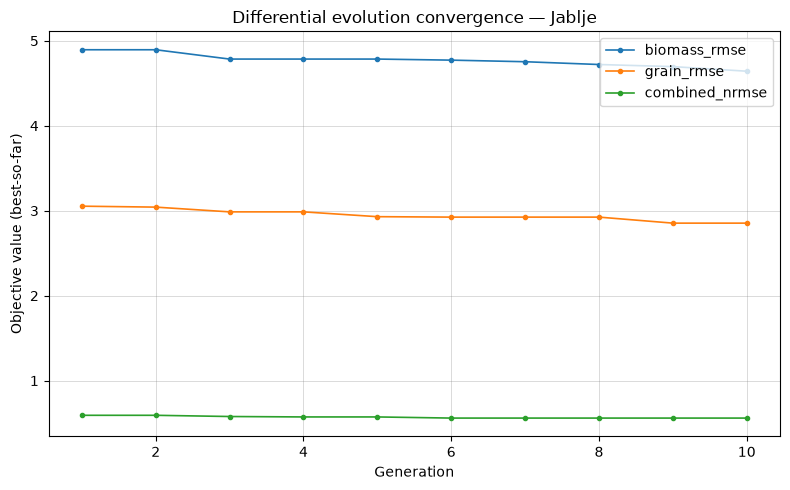

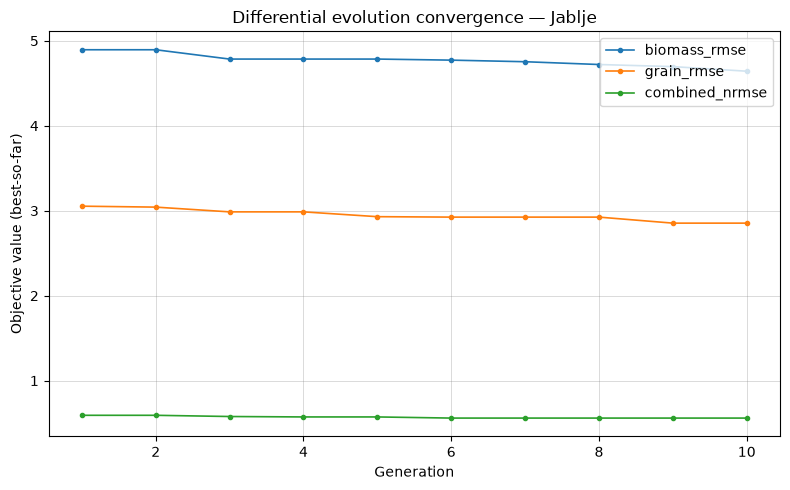

In [15]:
from aquacrop_slovenia.plots import plot_optimisation_convergence

# Convergence of each DE run: best-so-far objective value per generation
plot_optimisation_convergence(
    convergence_log,
    title="Differential evolution convergence — Jablje",
    ylabel="Objective value (best-so-far)",
)

In [16]:
display_cols = [
    "biomass_rmse", "biomass_r2", "biomass_nse", "biomass_kge", "biomass_mkge",
    "grain_rmse",   "grain_r2",   "grain_nse",   "grain_kge",   "grain_mkge",
]
print("Metric comparison across optimisation targets:")
summary_df[display_cols].round(4)

,biomass_rmse,biomass_r2,biomass_nse,biomass_kge,biomass_mkge,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge
optimised_for,,,,,,,,,,
biomass_rmse,4.6416,-0.1428,-0.1428,0.1599,0.1789,2.9560,-1.0753,-1.0753,0.2646,0.3483
grain_rmse,5.0985,-0.3788,-0.3788,-0.1510,-0.1557,2.8537,-0.9341,-0.9341,-0.0851,-0.0455
combined_nrmse,4.6735,-0.1585,-0.1585,0.0659,0.0757,2.8589,-0.9412,-0.9412,0.1789,0.2497


In [17]:
# Collect all evaluated candidates from the last DE run (combined) into a DataFrame
all_evals_df = pd.DataFrame(eval_log)
print(f"Total evaluations stored from last run: {len(all_evals_df)}")
all_evals_df.sort_values("biomass_rmse").head(10)

,gdd_emergence,gdd_max_rooting,gdd_senescence,gdd_maturity,max_canopy_cover,min_rooting_depth,max_rooting_depth,p_upper_senescence,p_upper_stomata,biomass_rmse,...,biomass_mkge_alpha,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
1494,6.384974,960.16354,981.358822,1157.384206,0.961649,0.374924,0.741245,0.70101,0.497654,4.673514,...,0.595732,2.858916,-0.941161,-0.941161,0.1789,0.24967,0.335019,0.782271,0.57035,0.729095
1490,6.384974,960.16354,981.358822,1157.384206,0.961649,0.374924,0.741245,0.70101,0.497654,4.673514,...,0.595732,2.858916,-0.941161,-0.941161,0.1789,0.24967,0.335019,0.782271,0.57035,0.729095
1489,6.384974,960.16354,981.358822,1157.384206,0.961649,0.374924,0.741245,0.70101,0.497654,4.673514,...,0.595732,2.858916,-0.941161,-0.941161,0.1789,0.24967,0.335019,0.782271,0.57035,0.729095
1488,6.384974,960.16354,981.358822,1157.384206,0.961649,0.374924,0.741245,0.70101,0.497654,4.673514,...,0.595732,2.858916,-0.941161,-0.941161,0.1789,0.24967,0.335019,0.782271,0.57035,0.729095
1486,6.384974,960.16354,981.358822,1157.384206,0.961649,0.374924,0.741245,0.70101,0.497654,4.673514,...,0.595732,2.858916,-0.941161,-0.941161,0.1789,0.24967,0.335019,0.782271,0.57035,0.729095
1487,6.384974,960.16354,981.358822,1157.384206,0.961649,0.374924,0.741245,0.70101,0.497654,4.673514,...,0.595732,2.858916,-0.941161,-0.941161,0.1789,0.24967,0.335019,0.782271,0.57035,0.729095
1485,6.384974,960.16354,981.358822,1157.384206,0.961649,0.374924,0.741245,0.70101,0.497654,4.673514,...,0.595732,2.858916,-0.941161,-0.941161,0.1789,0.24967,0.335019,0.782271,0.57035,0.729095
890,6.384974,960.16354,981.358822,1157.384206,0.961649,0.374924,0.741245,0.70101,0.497654,4.673514,...,0.595732,2.858916,-0.941161,-0.941161,0.1789,0.24967,0.335019,0.782271,0.57035,0.729095
1492,6.384974,960.16354,981.358822,1157.384206,0.961649,0.374924,0.741245,0.70101,0.497654,4.673514,...,0.595732,2.858916,-0.941161,-0.941161,0.1789,0.24967,0.335019,0.782271,0.57035,0.729095
1493,6.384974,960.16354,981.358822,1157.384206,0.961649,0.374924,0.741245,0.70101,0.497654,4.673514,...,0.595732,2.858916,-0.941161,-0.941161,0.1789,0.24967,0.335019,0.782271,0.57035,0.729095


In [18]:
output_path = config.RESULTS_DIR / "de_jablje_summary.pkl"
summary_df.reset_index().to_pickle(output_path)
print(f"Saved summary ({len(summary_df)} rows) to {output_path}")

In [19]:
# Visualise the best solution for each target
def rerun_best(param_values, label):
    """Re-run a full simulation with given params and return seasonal results."""
    params = copy.deepcopy(jablje_maize_params)
    for name, val in zip(param_names, param_values):
        params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

    best_dir = config.MODEL_RUNNING_DIR / f"de_jablje_best_{label}"
    best_dir.mkdir(parents=True, exist_ok=True)

    sim = AquaCrop(
        simulation_periods=simulation_periods,
        crop=Crop(name=f"{LOCATION} maize ({label})", description=label, params=params),
        soil=soil,
        management=jablje_management,
        initial_conditions=jablje_initial_cond,
        climate=weather,
        ground_water=jablje_groundwater,
        working_dir=best_dir,
        need_daily_output=False,
        need_seasonal_output=True,
        need_harvest_output=False,
        need_evaluation_output=False,
    )
    return sim.run()["season"]

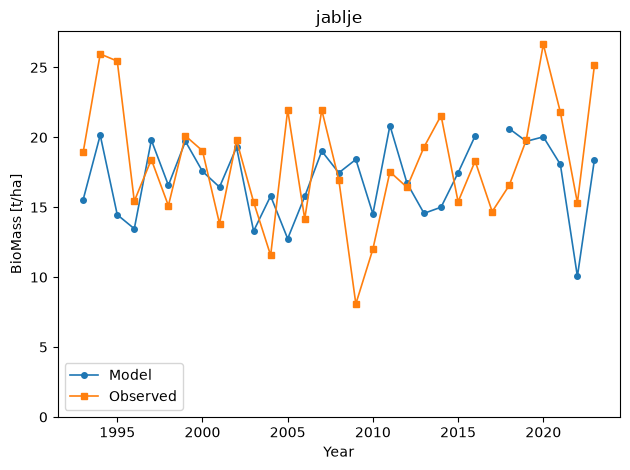

In [20]:
seasonal_biomass_opt = rerun_best(result_biomass.x, "biomass_opt")
print("=== Best solution optimised for biomass RMSE ===")
plot_yield_timeseries_comparison(seasonal_biomass_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass", LOCATION)

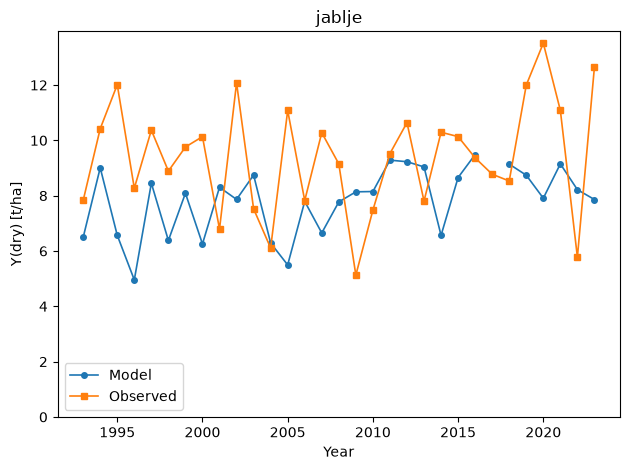

In [21]:
seasonal_grain_opt = rerun_best(result_grain.x, "grain_opt")
print("=== Best solution optimised for grain RMSE ===")
plot_yield_timeseries_comparison(seasonal_grain_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)", LOCATION)

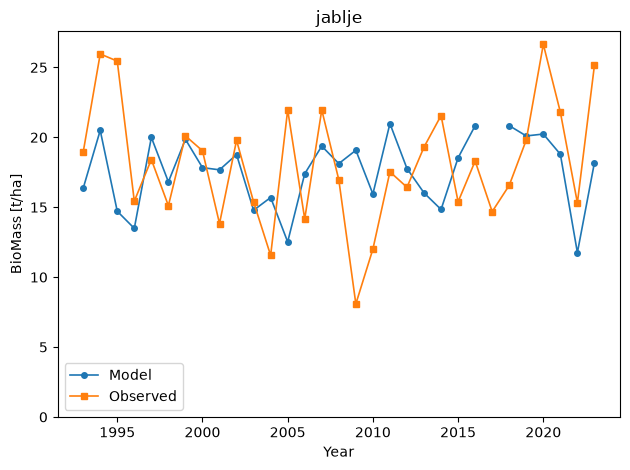

In [22]:
seasonal_combined_opt = rerun_best(result_combined.x, "combined_opt")
print("=== Best solution optimised for combined nRMSE ===")
plot_yield_timeseries_comparison(seasonal_combined_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass", LOCATION)

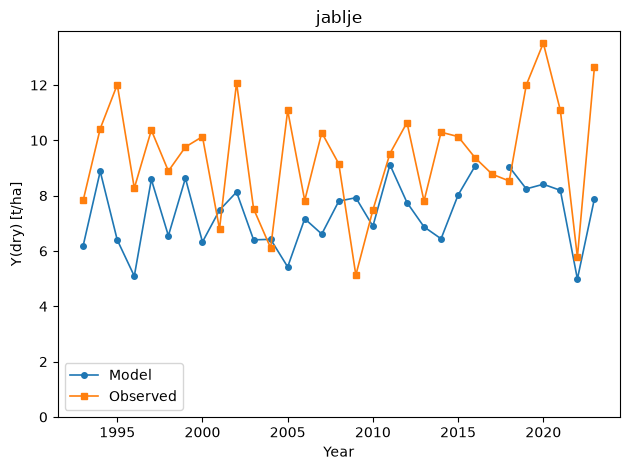

In [23]:
plot_yield_timeseries_comparison(seasonal_combined_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)", LOCATION)